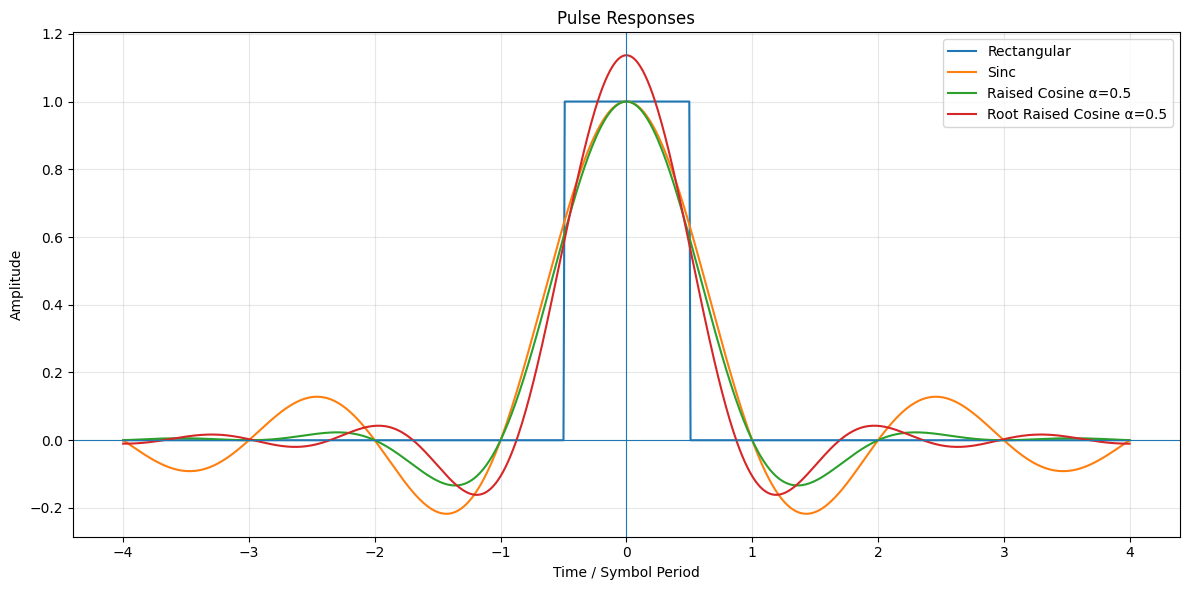

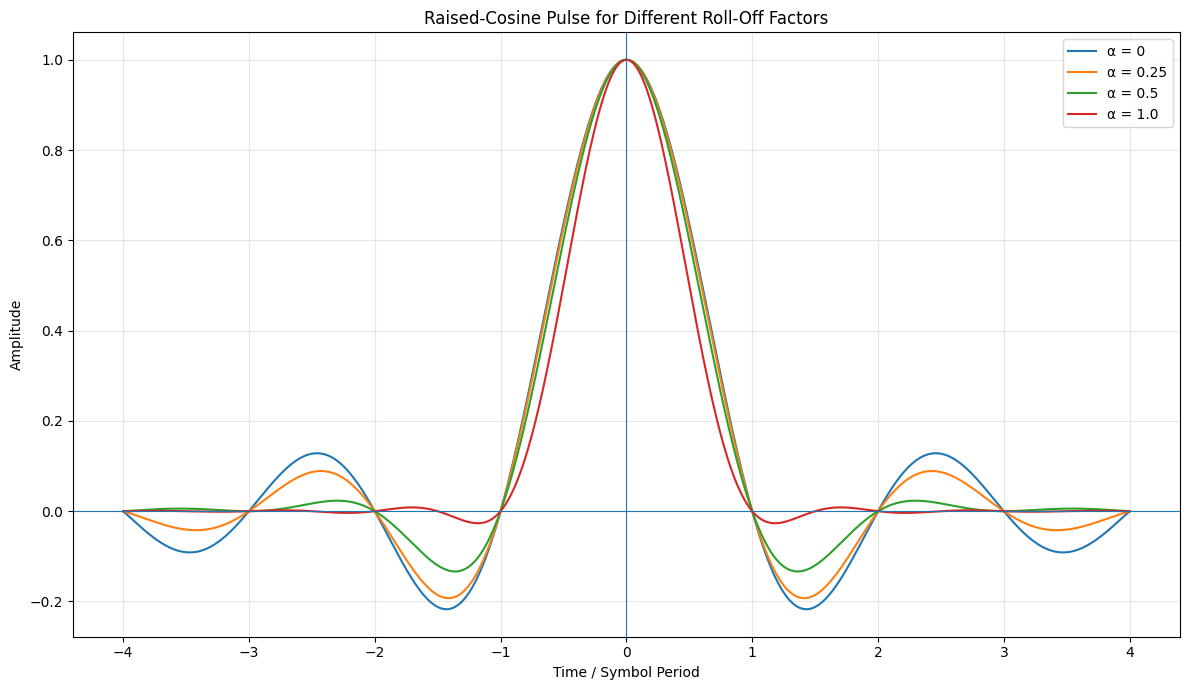

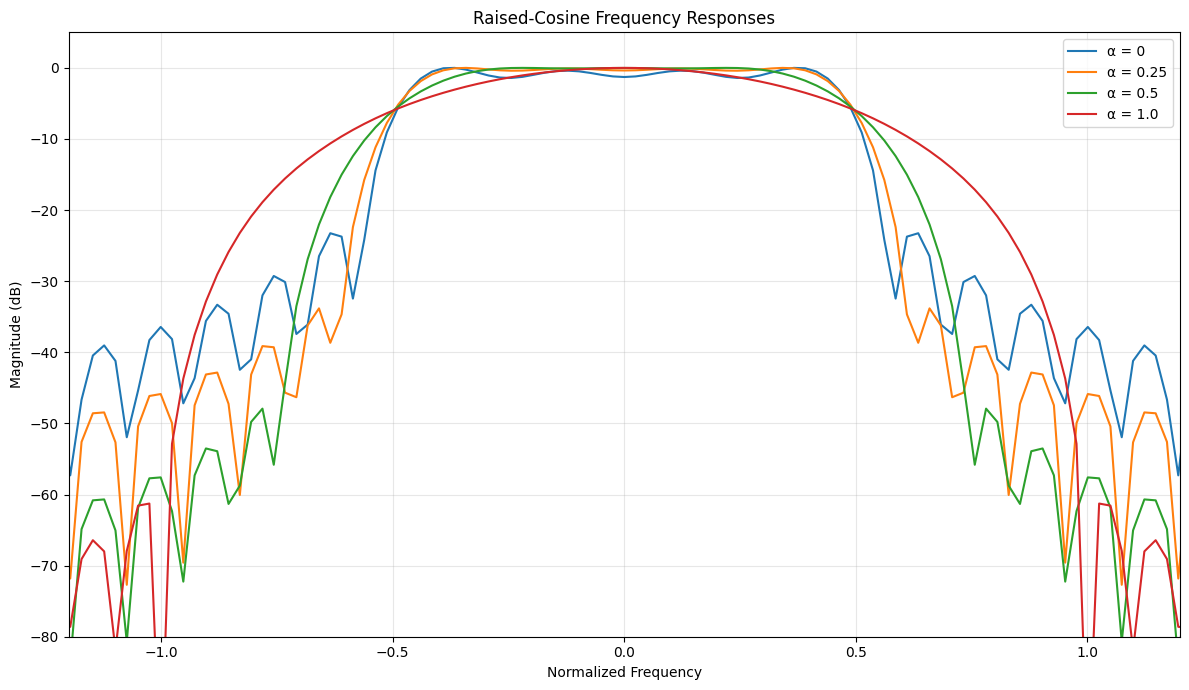

NYQUIST ZERO-CROSSING VERIFICATION

Roll-off factor α = 0
t = -4Ts : -0.000000
t = -3Ts : 0.000000
t = -2Ts : -0.000000
t = -1Ts : 0.000000
t = +0Ts : 1.000000
t = +1Ts : 0.000000
t = +2Ts : -0.000000
t = +3Ts : 0.000000
t = +4Ts : -0.000000

Roll-off factor α = 0.25
t = -4Ts : -0.000000
t = -3Ts : 0.000000
t = -2Ts : -0.000000
t = -1Ts : 0.000000
t = +0Ts : 1.000000
t = +1Ts : 0.000000
t = +2Ts : -0.000000
t = +3Ts : 0.000000
t = +4Ts : -0.000000

Roll-off factor α = 0.5
t = -4Ts : 0.000000
t = -3Ts : 0.000000
t = -2Ts : -0.000000
t = -1Ts : 0.000000
t = +0Ts : 1.000000
t = +1Ts : 0.000000
t = +2Ts : -0.000000
t = +3Ts : 0.000000
t = +4Ts : 0.000000

Roll-off factor α = 1.0
t = -4Ts : 0.000000
t = -3Ts : 0.000000
t = -2Ts : 0.000000
t = -1Ts : 0.000000
t = +0Ts : 1.000000
t = +1Ts : 0.000000
t = +2Ts : 0.000000
t = +3Ts : 0.000000
t = +4Ts : 0.000000


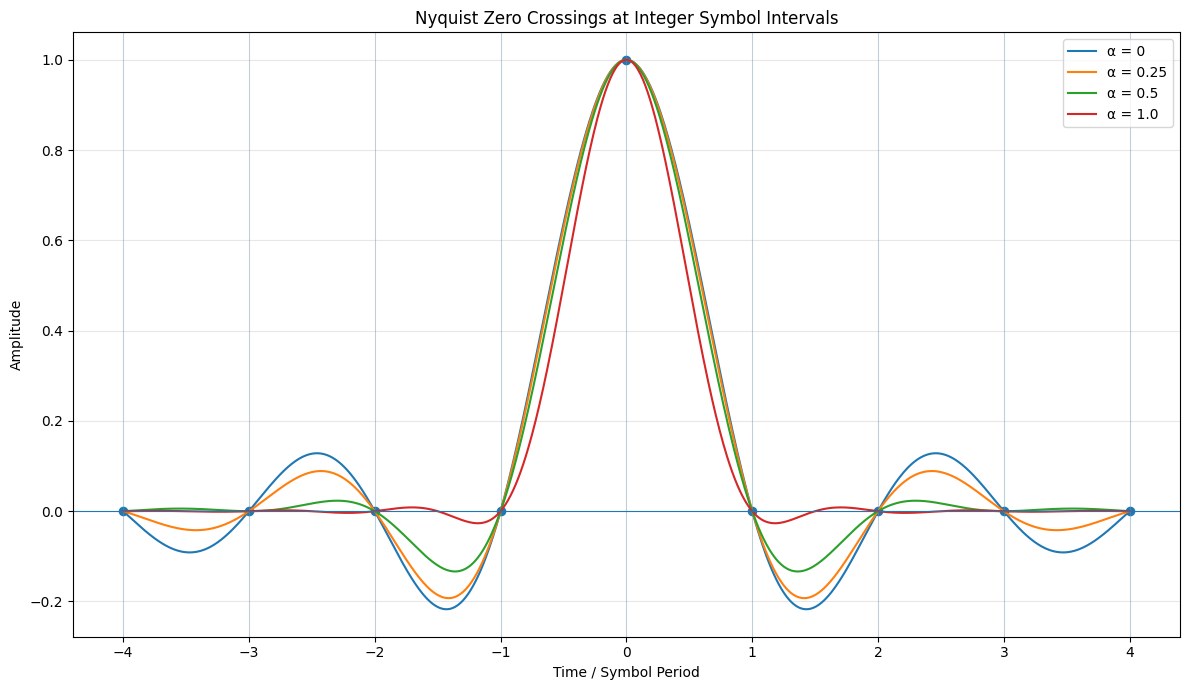

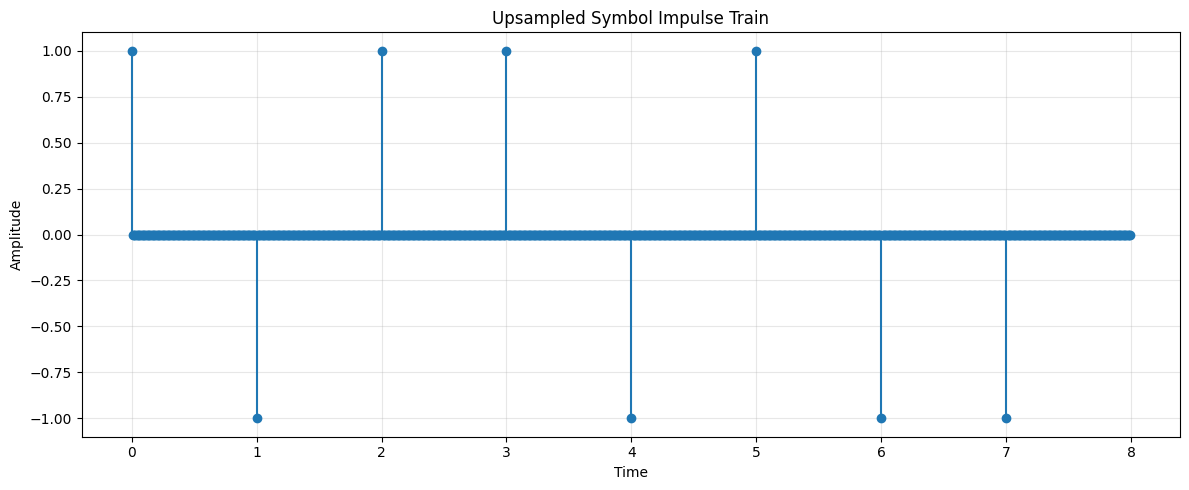

ValueError: x and y must have same first dimension, but have shapes (800,) and (801,)

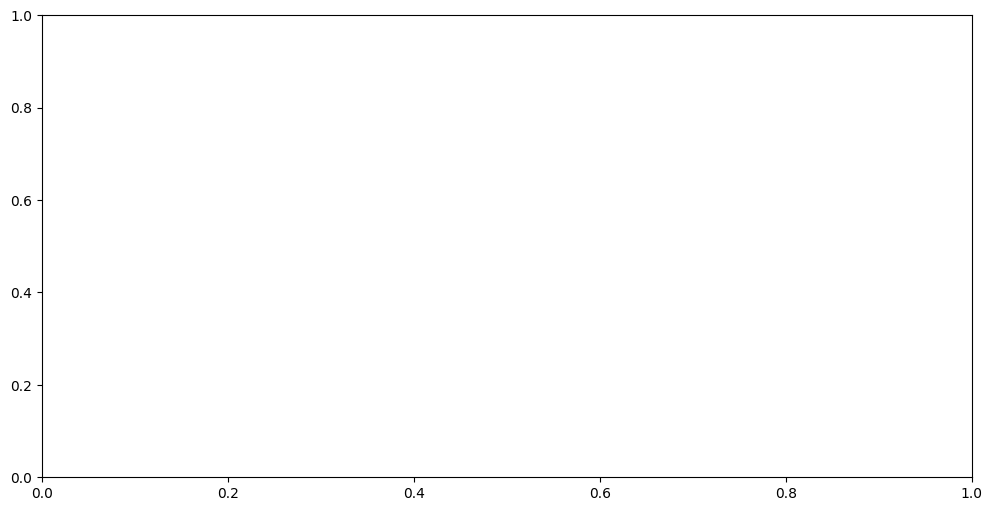

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

# ============================================================
# EXPERIMENT 7
# PULSE SHAPING AND THE NYQUIST CRITERION
# ============================================================

# Parameters
Ts = 1.0                 # Symbol period
sps = 100                # Samples per symbol
num_symbols = 8
alphas = [0, 0.25, 0.5, 1.0]

# Time axis
span = 8                 # Pulse span in symbols
t = np.arange(-span * Ts / 2,
              span * Ts / 2 + Ts / sps,
              Ts / sps)


# ============================================================
# 1. RECTANGULAR PULSE
# ============================================================

def rectangular_pulse(t, Ts):
    return np.where(np.abs(t) <= Ts / 2, 1.0, 0.0)


# ============================================================
# 2. SINC PULSE
# ============================================================

def sinc_pulse(t, Ts):
    return np.sinc(t / Ts)


# ============================================================
# 3. RAISED COSINE PULSE
# ============================================================

def raised_cosine(t, Ts, alpha):

    x = t / Ts
    p = np.zeros_like(x, dtype=float)

    if alpha == 0:
        return np.sinc(x)

    # Normal case
    denominator = 1 - (2 * alpha * x) ** 2
    normal = np.abs(denominator) > 1e-10

    p[normal] = (
        np.sinc(x[normal])
        * np.cos(np.pi * alpha * x[normal])
        / denominator[normal]
    )

    # Singularity locations: t = +/- Ts/(2 alpha)
    singular = np.isclose(
        np.abs(x),
        1 / (2 * alpha),
        atol=1e-10
    )

    p[singular] = (
        alpha / 2
        * np.sin(np.pi / (2 * alpha))
    )

    return p


# ============================================================
# 4. ROOT RAISED COSINE PULSE
# ============================================================

def root_raised_cosine(t, Ts, alpha):

    x = t / Ts
    h = np.zeros_like(x, dtype=float)

    if alpha == 0:
        return np.sinc(x)

    # t = 0
    zero_point = np.isclose(x, 0, atol=1e-10)

    h[zero_point] = (
        1
        + alpha
        * (4 / np.pi - 1)
    )

    # t = +/- Ts/(4 alpha)
    special = np.isclose(
        np.abs(x),
        1 / (4 * alpha),
        atol=1e-10
    )

    h[special] = (
        alpha / np.sqrt(2)
        * (
            (1 + 2 / np.pi)
            * np.sin(np.pi / (4 * alpha))
            +
            (1 - 2 / np.pi)
            * np.cos(np.pi / (4 * alpha))
        )
    )

    # General case
    normal = ~(zero_point | special)

    numerator = (
        np.sin(
            np.pi * x[normal] * (1 - alpha)
        )
        +
        4 * alpha * x[normal]
        * np.cos(
            np.pi * x[normal] * (1 + alpha)
        )
    )

    denominator = (
        np.pi
        * x[normal]
        * (
            1 - (4 * alpha * x[normal]) ** 2
        )
    )

    h[normal] = numerator / denominator

    return h


# ============================================================
# 5. PLOT BASIC PULSE RESPONSES
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    t,
    rectangular_pulse(t, Ts),
    label="Rectangular"
)

plt.plot(
    t,
    sinc_pulse(t, Ts),
    label="Sinc"
)

plt.plot(
    t,
    raised_cosine(t, Ts, 0.5),
    label="Raised Cosine α=0.5"
)

plt.plot(
    t,
    root_raised_cosine(t, Ts, 0.5),
    label="Root Raised Cosine α=0.5"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Time / Symbol Period")
plt.ylabel("Amplitude")
plt.title("Pulse Responses")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("01_pulse_responses.png", dpi=300)
plt.show()


# ============================================================
# 6. RAISED COSINE PULSES FOR DIFFERENT ROLL-OFF FACTORS
# ============================================================

plt.figure(figsize=(12, 7))

for alpha in alphas:

    pulse = raised_cosine(t, Ts, alpha)

    plt.plot(
        t,
        pulse,
        label=f"α = {alpha}"
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Time / Symbol Period")
plt.ylabel("Amplitude")
plt.title("Raised-Cosine Pulse for Different Roll-Off Factors")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("02_raised_cosine_rolloff.png", dpi=300)
plt.show()


# ============================================================
# 7. FREQUENCY RESPONSE
# ============================================================

NFFT = 4096

plt.figure(figsize=(12, 7))

for alpha in alphas:

    pulse = raised_cosine(t, Ts, alpha)

    spectrum = np.fft.fftshift(
        np.fft.fft(pulse, NFFT)
    )

    frequency = np.fft.fftshift(
        np.fft.fftfreq(
            NFFT,
            d=Ts / sps
        )
    )

    magnitude = np.abs(spectrum)

    magnitude = (
        magnitude / np.max(magnitude)
    )

    magnitude_db = 20 * np.log10(
        magnitude + 1e-12
    )

    plt.plot(
        frequency,
        magnitude_db,
        label=f"α = {alpha}"
    )

plt.xlim(-1.2, 1.2)
plt.ylim(-80, 5)

plt.xlabel("Normalized Frequency")
plt.ylabel("Magnitude (dB)")
plt.title("Raised-Cosine Frequency Responses")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("03_frequency_responses.png", dpi=300)
plt.show()


# ============================================================
# 8. NYQUIST ZERO-CROSSING VERIFICATION
# ============================================================

print("=" * 60)
print("NYQUIST ZERO-CROSSING VERIFICATION")
print("=" * 60)

integer_times = np.arange(
    -4,
    5
) * Ts

for alpha in alphas:

    pulse = raised_cosine(
        integer_times,
        Ts,
        alpha
    )

    print(f"\nRoll-off factor α = {alpha}")

    for k, value in zip(
        range(-4, 5),
        pulse
    ):
        print(
            f"t = {k:+d}Ts : "
            f"{value:.6f}"
        )


# ============================================================
# 9. PLOT ZERO CROSSINGS
# ============================================================

plt.figure(figsize=(12, 7))

for alpha in alphas:

    pulse = raised_cosine(t, Ts, alpha)

    plt.plot(
        t,
        pulse,
        label=f"α = {alpha}"
    )

for k in range(-4, 5):

    plt.axvline(
        k * Ts,
        linewidth=0.5,
        alpha=0.3
    )

plt.scatter(
    integer_times,
    raised_cosine(
        integer_times,
        Ts,
        0.5
    ),
    s=35
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Time / Symbol Period")
plt.ylabel("Amplitude")
plt.title("Nyquist Zero Crossings at Integer Symbol Intervals")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("04_nyquist_zero_crossings.png", dpi=300)
plt.show()


# ============================================================
# 10. CREATE UPSAMPLED SYMBOL IMPULSE TRAIN
# ============================================================

symbols = np.array(
    [1, -1, 1, 1, -1, 1, -1, -1]
)

upsampled = np.zeros(
    len(symbols) * sps
)

upsampled[::sps] = symbols

stream_time = np.arange(
    len(upsampled)
) * Ts / sps

plt.figure(figsize=(12, 5))

plt.stem(
    stream_time,
    upsampled,
    basefmt=" "
)

plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Upsampled Symbol Impulse Train")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("05_symbol_impulse_train.png", dpi=300)
plt.show()


# ============================================================
# 11. PULSE-SHAPED SYMBOL STREAM
# ============================================================

alpha_stream = 0.5

pulse_stream = root_raised_cosine(
    t,
    Ts,
    alpha_stream
)

shaped_stream = np.convolve(
    upsampled,
    pulse_stream,
    mode="same"
)

plt.figure(figsize=(12, 6))

plt.plot(
    stream_time,
    shaped_stream,
    label="Pulse-shaped stream"
)

plt.stem(
    stream_time[::sps],
    symbols,
    linefmt="--",
    markerfmt="o",
    basefmt=" ",
    label="Original symbols"
)

plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title(
    "Pulse-Shaped Symbol Stream "
    "(Root Raised Cosine, α=0.5)"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("06_pulse_shaped_stream.png", dpi=300)
plt.show()


# ============================================================
# 12. TRANSMITTER + RECEIVER RRC CASCADE
# ============================================================

tx_rrc = root_raised_cosine(
    t,
    Ts,
    alpha_stream
)

rx_rrc = root_raised_cosine(
    t,
    Ts,
    alpha_stream
)

# Cascade
overall_rc = np.convolve(
    tx_rrc,
    rx_rrc,
    mode="full"
)

overall_rc = (
    overall_rc
    / np.max(np.abs(overall_rc))
)

cascade_time = (
    np.arange(len(overall_rc))
    - (len(overall_rc) - 1) / 2
) * Ts / sps

plt.figure(figsize=(12, 6))

plt.plot(
    cascade_time / Ts,
    overall_rc,
    label="TX RRC * RX RRC"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Time / Symbol Period")
plt.ylabel("Amplitude")
plt.title(
    "Transmitter and Receiver RRC Cascade"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("07_rrc_cascade.png", dpi=300)
plt.show()


# ============================================================
# 13. MANDATORY VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("MANDATORY VALIDATION")
print("=" * 60)

# Sample overall RC response at integer symbol intervals

sample_indices = []

for k in range(-4, 5):

    target_time = k * Ts

    index = np.argmin(
        np.abs(
            cascade_time
            - target_time
        )
    )

    sample_indices.append(index)


print("\nOverall RC response at integer symbol intervals:")
print("-" * 45)
print(
    f"{'k':>5} {'Time':>12} {'Amplitude':>15}"
)
print("-" * 45)

validation_table = []

for k, index in zip(
    range(-4, 5),
    sample_indices
):

    value = overall_rc[index]

    validation_table.append(
        [k, k * Ts, value]
    )

    print(
        f"{k:>5} "
        f"{k * Ts:>12.3f} "
        f"{value:>15.6f}"
    )


# ============================================================
# 14. BANDWIDTH VS ROLL-OFF
# ============================================================

bandwidth_values = []

for alpha in alphas:

    bandwidth = (
        (1 + alpha)
        / (2 * Ts)
    )

    bandwidth_values.append(
        bandwidth
    )

plt.figure(figsize=(10, 6))

plt.plot(
    alphas,
    bandwidth_values,
    marker="o"
)

plt.xlabel("Roll-Off Factor α")
plt.ylabel("Bandwidth")
plt.title("Bandwidth vs Roll-Off Factor")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("08_bandwidth_vs_rolloff.png", dpi=300)
plt.show()


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)

print("Symbol period:", Ts)
print("Samples per symbol:", sps)
print("Roll-off factors:", alphas)

print("\nPulse types:")
print("- Rectangular")
print("- Sinc")
print("- Raised Cosine")
print("- Root Raised Cosine")

print("\nRequired analyses completed:")
print("1. Pulse responses")
print("2. Frequency responses")
print("3. Upsampled symbol impulse train")
print("4. Pulse-shaped symbol stream")
print("5. Nyquist zero-crossing verification")
print("6. Transmitter and receiver RRC cascade")
print("7. Mandatory integer-symbol sampling")
print("8. Bandwidth versus roll-off")

print("\nExperiment 7 completed successfully.")